In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install pennylane pennylane-lightning --upgrade -q

import pennylane as qml
import pennylane.math as qmath
import torch
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

sns.set_style("whitegrid")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 108.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 69.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.0 MB/s eta 0:00:00
Using device: cuda:0


In [ ]:

df_train   = pd.read_parquet("/kaggle/input/datasets/arjunenaik/cicio3-data/DATA_QC/q8_train.parquet")
df_test    = pd.read_parquet("/kaggle/input/datasets/arjunenaik/cicio3-data/DATA_QC/q8_test.parquet")
df_cal     = pd.read_parquet("/kaggle/input/datasets/arjunenaik/cicio3-data/DATA_QC/q8_calibration.parquet")
df_zeroday = pd.read_parquet("/kaggle/input/datasets/arjunenaik/cicio3-data/DATA_QC/q8_zeroday.parquet")

for name, df in [("train", df_train), ("test", df_test), ("cal", df_cal), ("zeroday", df_zeroday)]:
    print(f"{name}: {df.shape}")

df_train.head()

train: (132166, 11)
test: (18883, 11)
cal: (18883, 11)
zeroday: (10984, 11)


,urg_count,Duration,flow_duration,Variance,Std,HTTPS,Tot sum,Header_Length,label_multiclass,label_binary,label_family
0,0.022648,2.364978,0.003637,0.000000,0.017957,0.000000,1.057962,0.860762,DDoS-RSTFINFlood,1,ddos
1,1.162439,3.045862,0.378237,2.909113,1.699442,3.141593,1.142228,2.621899,BenignTraffic,0,benign
2,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,0.944141,0.000000,DDoS-ICMP_Flood,1,ddos
3,0.000000,2.363669,0.000071,0.472997,0.679082,0.000000,1.075915,0.791950,DDoS-TCP_Flood,1,ddos
4,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,1.057771,0.782123,DDoS-RSTFINFlood,1,ddos


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132166 entries, 0 to 132165
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   urg_count         132166 non-null  float64
 1   Duration          132166 non-null  float64
 2   flow_duration     132166 non-null  float64
 3   Variance          132166 non-null  float64
 4   Std               132166 non-null  float64
 5   HTTPS             132166 non-null  float64
 6   Tot sum           132166 non-null  float64
 7   Header_Length     132166 non-null  float64
 8   label_multiclass  132166 non-null  object 
 9   label_binary      132166 non-null  int8   
 10  label_family      132166 non-null  object 
dtypes: float64(8), int8(1), object(2)
memory usage: 10.2+ MB


In [4]:
df_train.label_multiclass.value_counts()


label_multiclass
DDoS-ICMP_Flood            21177
DDoS-UDP_Flood             15878
DDoS-TCP_Flood             13249
DDoS-PSHACK_Flood          11988
DDoS-SYN_Flood             11947
DDoS-RSTFINFlood           11816
DDoS-SynonymousIP_Flood    10561
DoS-UDP_Flood               9711
DoS-TCP_Flood               7803
DoS-SYN_Flood               5947
BenignTraffic               3202
DDoS-ICMP_Fragmentation     1331
DoS-HTTP_Flood              1271
MITM-ArpSpoofing             901
DDoS-UDP_Fragmentation       840
DDoS-ACK_Fragmentation       837
VulnerabilityScan            630
DNS_Spoofing                 530
DDoS-HTTP_Flood              491
DDoS-SlowLoris               431
Recon-HostDiscovery          405
Recon-OSScan                 289
Recon-PortScan               242
DictionaryBruteForce         201
BrowserHijacking             109
SqlInjection                 101
CommandInjection              93
Backdoor_Malware              66
XSS                           63
Recon-PingSweep           

Raw train multiclass distribution:
label_multiclass
DDoS-ICMP_Flood            21177
DDoS-UDP_Flood             15878
DDoS-TCP_Flood             13249
DDoS-PSHACK_Flood          11988
DDoS-SYN_Flood             11947
DDoS-RSTFINFlood           11816
DDoS-SynonymousIP_Flood    10561
DoS-UDP_Flood               9711
DoS-TCP_Flood               7803
DoS-SYN_Flood               5947
BenignTraffic               3202
DDoS-ICMP_Fragmentation     1331
DoS-HTTP_Flood              1271
MITM-ArpSpoofing             901
DDoS-UDP_Fragmentation       840
DDoS-ACK_Fragmentation       837
VulnerabilityScan            630
DNS_Spoofing                 530
DDoS-HTTP_Flood              491
DDoS-SlowLoris               431
Recon-HostDiscovery          405
Recon-OSScan                 289
Recon-PortScan               242
DictionaryBruteForce         201
BrowserHijacking             109
SqlInjection                 101
CommandInjection              93
Backdoor_Malware              66
XSS                     

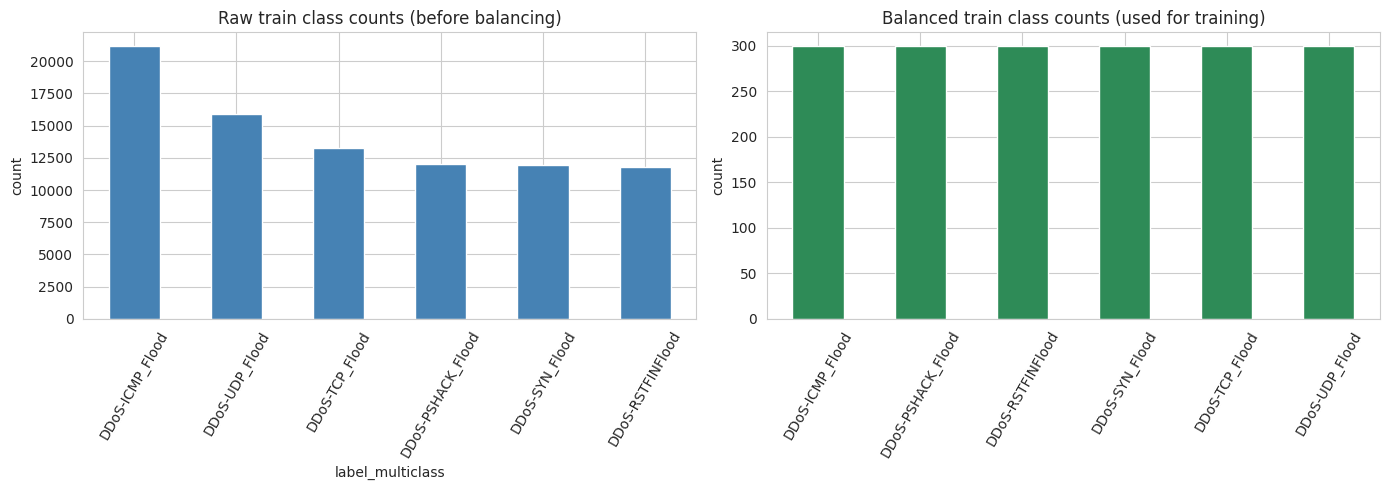

In [ ]:

from sklearn.preprocessing import LabelEncoder


for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_binary"], inplace=True, errors="ignore")

print("Raw train multiclass distribution:")
print(df_train.label_multiclass.value_counts())


MAX_CLASSES = 6  
top_classes = df_train.label_multiclass.value_counts().head(MAX_CLASSES).index.tolist() \
              if MAX_CLASSES else df_train.label_multiclass.unique().tolist()
print(f"\nUsing top {len(top_classes)} classes: {top_classes}")

df_train_f   = df_train[df_train.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_test_f    = df_test[df_test.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_cal_f     = df_cal[df_cal.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_zeroday_f = df_zeroday.reset_index(drop=True) 


le = LabelEncoder()
le.fit(top_classes)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"\nEncoded classes ({N_CLASSES}): {dict(enumerate(CLASS_NAMES))}")


PER_CLASS_CAP = 300  
balanced_parts = []
for cls in top_classes:
    cls_df = df_train_f[df_train_f.label_multiclass == cls]
    n_take = min(PER_CLASS_CAP, len(cls_df))
    balanced_parts.append(cls_df.iloc[:n_take])
df_cleaned_train = pd.concat(balanced_parts, ignore_index=True)

df_cleaned_test    = df_test_f.iloc[:4000].reset_index(drop=True)
df_cleaned_cal      = df_cal_f.iloc[:4000].reset_index(drop=True)
df_cleaned_zeroday  = df_zeroday_f.iloc[:2000].reset_index(drop=True)

print("\nBalanced train class counts:")
print(df_cleaned_train.label_multiclass.value_counts())

feature_columns = [c for c in df_train.columns if c != "label_multiclass"]
target_column = "label_multiclass"

X_train = df_cleaned_train[feature_columns]
y_train = pd.Series(le.transform(df_cleaned_train[target_column]))

X_test = df_cleaned_test[feature_columns]
y_test = pd.Series(le.transform(df_cleaned_test[target_column]))

X_cal = df_cleaned_cal[feature_columns]
y_cal = pd.Series(le.transform(df_cleaned_cal[target_column]))

X_zeroday = df_cleaned_zeroday[feature_columns]  # unseen-class set, no labels transformed

print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Shape of X_cal:   {X_cal.shape}, y_cal:   {y_cal.shape}")
print(f"Shape of X_zeroday: {X_zeroday.shape}")


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df_train_f.label_multiclass.value_counts().loc[top_classes].plot(
    kind="bar", ax=ax[0], color="steelblue"
)
ax[0].set_title("Raw train class counts (before balancing)")
ax[0].set_ylabel("count"); ax[0].tick_params(axis='x', rotation=60)

y_train.value_counts().sort_index().plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_xticklabels(CLASS_NAMES, rotation=60)
ax[1].set_title("Balanced train class counts (used for training)")
ax[1].set_ylabel("count")

plt.tight_layout(); plt.show()

Original feature count: 8
PCA components retained (>=95% variance): 7
Cumulative explained variance: 97.75%

A_train: (1800, 7), A_cal: (4000, 7), A_test: (4000, 7), A_zday: (2000, 7)
N_FEATURES (post-PCA) = 7, N_CLASSES = 6


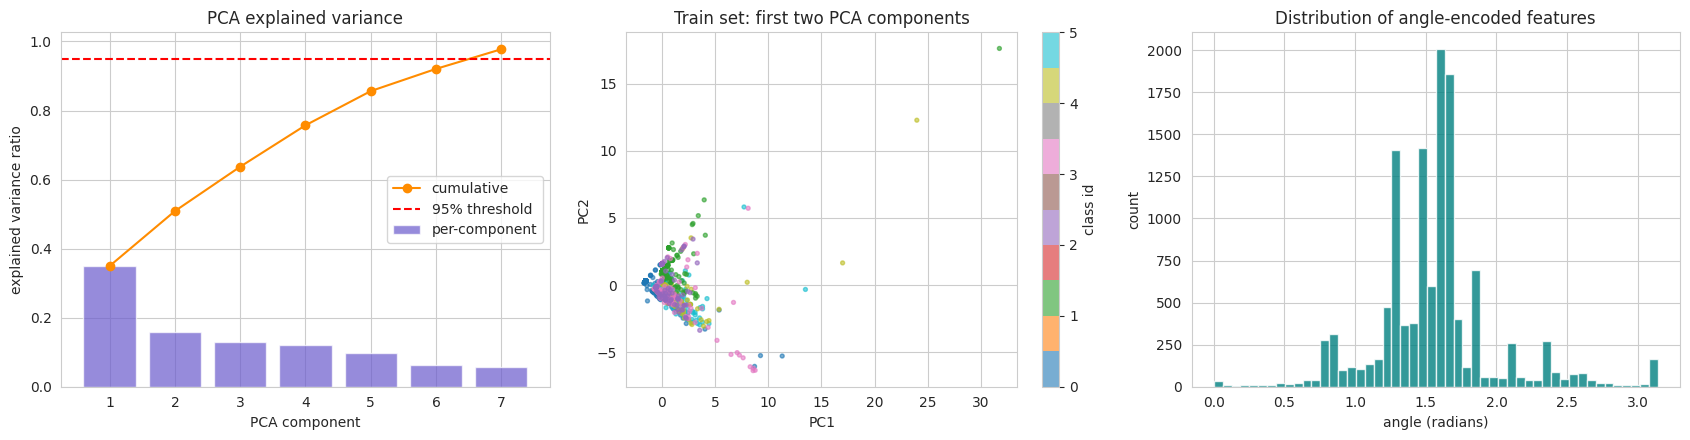

In [ ]:

# StandardScaler -> PCA (95% variance) -> angle encoding
#   + explained-variance visualization

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_cal_scaled   = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
X_cal_pca   = pca.transform(X_cal_scaled)
X_zeroday_pca = pca.transform(X_zeroday_scaled)

n_components = pca.n_components_
cum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"PCA components retained (>=95% variance): {n_components}")
print(f"Cumulative explained variance: {cum_var[-1]*100:.2f}%")

def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi

A_train, A_cal, A_test, A_zday = map(
    to_angles, [X_train_pca, X_cal_pca, X_test_pca, X_zeroday_pca]
)

N_FEATURES = A_train.shape[1]
print(f"\nA_train: {A_train.shape}, A_cal: {A_cal.shape}, A_test: {A_test.shape}, A_zday: {A_zday.shape}")
print(f"N_FEATURES (post-PCA) = {N_FEATURES}, N_CLASSES = {N_CLASSES}")

#  PCA variance  2D projection 
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_,
          color="slateblue", alpha=0.7, label="per-component")
ax[0].plot(range(1, len(cum_var) + 1), cum_var, marker='o', color="darkorange", label="cumulative")
ax[0].axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax[0].set_xlabel("PCA component"); ax[0].set_ylabel("explained variance ratio")
ax[0].set_title("PCA explained variance"); ax[0].legend()

# 2D scatter of first two PCA components, colored by class
sc = ax[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="tab10", s=8, alpha=0.6)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("Train set: first two PCA components")
plt.colorbar(sc, ax=ax[1], ticks=range(N_CLASSES), label="class id")

# Angle-encoded feature histogram (sanity check: should lie in [0, pi])
ax[2].hist(A_train.flatten(), bins=50, color="teal", alpha=0.8)
ax[2].set_xlabel("angle (radians)"); ax[2].set_ylabel("count")
ax[2].set_title("Distribution of angle-encoded features")

plt.tight_layout(); plt.show()

[grad-variance probe] mean=-1.208e-03  var=3.168e-09  (BARREN PLATEAU RISK)


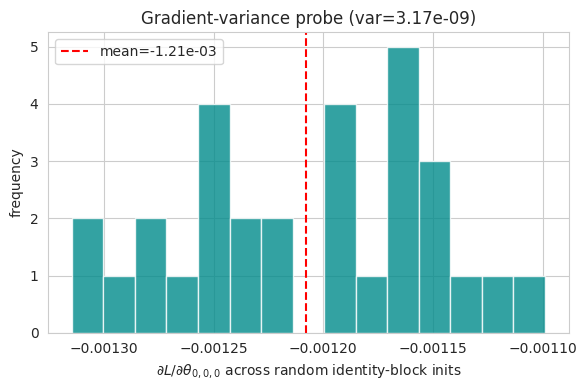

In [ ]:

#  (DAY 8): Mixed-state VQC on default.mixed
#   + identity-block init (barren-plateau safe)
#   + gradient-variance monitor

N_QUBITS = 5
N_LAYERS = 3
NOISE_P  = 0.01

dev = qml.device("default.mixed", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def state_circuit_batched(x_batch, theta):
    n_feat = x_batch.shape[1]
    for layer in range(N_LAYERS):
        for w in range(N_QUBITS):
            qml.RY(x_batch[:, w % n_feat], wires=w)
            qml.RZ(x_batch[:, (w + 1) % n_feat], wires=w)
        for w in range(N_QUBITS):
            qml.RY(theta[layer, w, 0], wires=w)
            qml.RZ(theta[layer, w, 1], wires=w)
        for w in range(N_QUBITS):
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
        for w in range(N_QUBITS):
            qml.DepolarizingChannel(NOISE_P, wires=w)
    return qml.density_matrix(wires=range(N_QUBITS))


def init_theta_identity_block(n_layers=N_LAYERS, n_qubits=N_QUBITS, eps=1e-2, dev_=device):
    theta = eps * torch.randn(n_layers, n_qubits, 2, device=dev_)
    return nn.Parameter(theta)


def _build_pauliZ_ops(n_qubits, dev_):
    I = torch.eye(2, dtype=torch.cdouble, device=dev_)
    Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cdouble, device=dev_)
    ops = []
    for w in range(n_qubits):
        mats = [Z if i == w else I for i in range(n_qubits)]
        op = mats[0]
        for m in mats[1:]:
            op = torch.kron(op, m)
        ops.append(op)
    return ops

PAULI_Z_OPS = _build_pauliZ_ops(N_QUBITS, device)

def expvals_from_rho_batch(rho_batch):
    return torch.stack([
        torch.stack([torch.real(torch.trace(rho @ op)) for op in PAULI_Z_OPS])
        for rho in rho_batch
    ])


def gradient_variance_probe(x_probe, n_trials=20, eps=1e-2):
    grad_samples = []
    for _ in range(n_trials):
        theta = init_theta_identity_block(eps=eps)
        rho = state_circuit_batched(x_probe, theta)
        loss = torch.stack([torch.real(torch.trace(r @ r)) for r in rho]).mean()
        loss.backward()
        grad_samples.append(theta.grad[0, 0, 0].item())
    grad_samples = np.array(grad_samples)
    var = grad_samples.var()
    print(f"[grad-variance probe] mean={grad_samples.mean():.3e}  var={var:.3e}  "
          f"({'OK' if var > 1e-6 else 'BARREN PLATEAU RISK'})")
    return var, grad_samples


probe_x = torch.tensor(A_train[:8], dtype=torch.float32, device=device)
grad_var, grad_samples = gradient_variance_probe(probe_x, n_trials=30)

# gradient distribution
plt.figure(figsize=(6, 4))
plt.hist(grad_samples, bins=15, color="darkcyan", alpha=0.8)
plt.axvline(grad_samples.mean(), color="red", linestyle="--", label=f"mean={grad_samples.mean():.2e}")
plt.xlabel(r"$\partial L / \partial \theta_{0,0,0}$ across random identity-block inits")
plt.ylabel("frequency")
plt.title(f"Gradient-variance probe (var={grad_var:.2e})")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:

#(DAY 9): Running class prototypes (N-CLASS) 

def safe_fidelity(rho, sigma, eps=1e-7):
    f = qmath.fidelity(rho, sigma)
    return torch.clamp(f, 0.0, 1.0 - eps)

def safe_trace_distance(rho, sigma):
    return torch.clamp(qmath.trace_distance(rho, sigma), 0.0, 1.0)


class RunningPrototypes:
    """EMA prototype rho_c per known class, updated every training batch.
    """
    def __init__(self, momentum=0.9):
        self.momentum = momentum
        self.protos = {}

    def batch_class_means(self, rho_batch, y_batch):
        means = {}
        for c in torch.unique(y_batch):
            c_int = int(c)
            mask = (y_batch == c)
            rhos_c = [rho_batch[j] for j in range(len(rho_batch)) if mask[j]]
            means[c_int] = sum(rhos_c) / len(rhos_c)
        return means

    def update(self, batch_means):
        for c_int, batch_mean in batch_means.items():
            if c_int not in self.protos:
                self.protos[c_int] = batch_mean.detach().clone()
            else:
                self.protos[c_int] = (self.momentum * self.protos[c_int]
                                       + (1 - self.momentum) * batch_mean.detach())
        return self.protos

    def diagnostics(self):
        """H1 diagnostic: pairwise inter-class trace distance for ALL class pairs."""
        keys = list(self.protos.keys())
        report = {}
        for a in range(len(keys)):
            for b in range(a + 1, len(keys)):
                d = safe_trace_distance(self.protos[keys[a]], self.protos[keys[b]]).item()
                report[f"D(rho_{keys[a]}, rho_{keys[b]})"] = d
        return report

    def pairwise_matrix(self, metric="trace_distance"):
        """Returns a full (n_classes x n_classes) matrix ."""
        keys = sorted(self.protos.keys())
        n = len(keys)
        M = np.zeros((n, n))
        for i, a in enumerate(keys):
            for j, b in enumerate(keys):
                if i == j:
                    M[i, j] = 0.0 if metric == "trace_distance" else 1.0
                else:
                    if metric == "trace_distance":
                        M[i, j] = safe_trace_distance(self.protos[a], self.protos[b]).item()
                    else:
                        M[i, j] = safe_fidelity(self.protos[a], self.protos[b]).item()
        return M, keys


#  (Ginibre-ensemble random density matrices) --> sample tests
_rng = np.random.default_rng(0)
def _random_density_matrix(n_qubits=N_QUBITS, dev_=device):
    dim = 2 ** n_qubits
    A = torch.tensor(_rng.normal(size=(dim, dim)) + 1j * _rng.normal(size=(dim, dim)),
                      dtype=torch.cdouble, device=dev_)
    rho = A @ A.conj().T
    return rho / torch.trace(rho)

r1, r2 = _random_density_matrix(), _random_density_matrix()
print("Fidelity(r1,r1)  ≈ 1:", safe_fidelity(r1, r1).item())
print("Fidelity(r1,r2):     ", safe_fidelity(r1, r2).item())
print("TraceDist(r1,r1) ≈ 0:", safe_trace_distance(r1, r1).item())
print("TraceDist(r1,r2):    ", safe_trace_distance(r1, r2).item())
assert abs(safe_fidelity(r1, r1).item() - 1.0) < 1e-3
assert safe_trace_distance(r1, r1).item() < 1e-3
print("Fidelity/trace-distance utilities verified.")

Fidelity(r1,r1)  ≈ 1: 0.9999999
Fidelity(r1,r2):      0.5796710079023886
TraceDist(r1,r1) ≈ 0: 0.0
TraceDist(r1,r2):     0.5630318728438279
Fidelity/trace-distance utilities verified.


In [ ]:

#(DAY 10): MAQT loss  L = L_CE + λ1·L_intra + λ2·L_inter


def focal_loss(logits, targets, gamma=2.0):
    ce = nn.functional.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()


def maqt_loss(rho_batch, y_batch, logits, prototypes: RunningPrototypes, lam1, lam2, gamma=2.0):
    L_CE = focal_loss(logits, y_batch, gamma=gamma)

    batch_means = prototypes.batch_class_means(rho_batch, y_batch)
    ema_protos = prototypes.update(batch_means)

    intra_terms = []
    for c in torch.unique(y_batch):
        c_int = int(c)
        mask = (y_batch == c)
        for j in range(len(rho_batch)):
            if mask[j]:
                intra_terms.append(1 - safe_fidelity(rho_batch[j], ema_protos[c_int]))
    L_intra = torch.stack(intra_terms).mean()

    keys = list(ema_protos.keys())
    inter_terms = []
    for a in range(len(keys)):
        for b in range(a + 1, len(keys)):
            inter_terms.append(safe_trace_distance(ema_protos[keys[a]], ema_protos[keys[b]]))
    L_inter = (-torch.stack(inter_terms).mean() if inter_terms
               else torch.tensor(0.0, device=rho_batch.device))

    total = L_CE + lam1 * L_intra + lam2 * L_inter
    return total, {"L_CE": L_CE.item(), "L_intra": L_intra.item(),
                    "L_inter": L_inter.item(), "L_total": total.item()}


# unit tests 
def _toy_multiclass_batch(n_per_class=6, n_classes=3, n_feat=N_FEATURES, seed=0):
    g = torch.Generator(device='cpu').manual_seed(seed)
    Xs, ys = [], []
    for c in range(n_classes):
        offset = c * (np.pi / n_classes)
        xc = torch.rand(n_per_class, n_feat, generator=g) * (np.pi / n_classes) + offset
        Xs.append(xc)
        ys.append(torch.full((n_per_class,), c, dtype=torch.long))
    X = torch.cat(Xs, dim=0).to(device)
    y = torch.cat(ys, dim=0).to(device)
    return X, y

def test_maqt_loss_terms_multiclass():
    n_classes_toy = 3
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, n_classes_toy).to(device)
    protos = RunningPrototypes(momentum=0.9)

    Xb, yb = _toy_multiclass_batch(n_classes=n_classes_toy)
    rho_batch = state_circuit_batched(Xb, theta)
    z_batch = expvals_from_rho_batch(rho_batch)
    logits = head(z_batch.to(torch.float32))

    loss, terms = maqt_loss(rho_batch, yb, logits, protos, lam1=0.5, lam2=0.1)
    assert torch.isfinite(loss)
    assert terms["L_intra"] >= 0
    loss.backward()
    assert theta.grad is not None and torch.isfinite(theta.grad).all()
    print("test_maqt_loss_terms_multiclass PASSED:", terms)
    print(f"  Number of inter-class pairs formed: {n_classes_toy * (n_classes_toy - 1) // 2}")

def test_lambda_scaling_monotonic():
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, 3).to(device)
    Xb, yb = _toy_multiclass_batch(n_classes=3)
    rho_batch = state_circuit_batched(Xb, theta)
    z_batch = expvals_from_rho_batch(rho_batch)
    logits = head(z_batch.to(torch.float32))

    losses = []
    for lam in [0.0, 0.3, 0.6]:
        protos = RunningPrototypes(momentum=0.9)
        l, _ = maqt_loss(rho_batch, yb, logits, protos, lam1=lam, lam2=0.0)
        losses.append(l.item())
    assert losses[0] <= losses[1] <= losses[2] + 1e-6, f"non-monotonic in λ1: {losses}"
    print("test_lambda_scaling_monotonic PASSED:", losses)

test_maqt_loss_terms_multiclass()
test_lambda_scaling_monotonic()

test_maqt_loss_terms_multiclass PASSED: {'L_CE': 0.4695526361465454, 'L_intra': 0.39595905162179257, 'L_inter': -0.8458755551888313, 'L_total': 0.5829446064385586}
  Number of inter-class pairs formed: 3
test_lambda_scaling_monotonic PASSED: [0.5529229044914246, 0.6717782922438087, 0.7906336799961928]


epoch  1/10 | loss 0.5869 | L_CE 0.5869 | L_intra 0.2513 | L_inter -0.6612 | grad_var 1.57e-03 | intra_fid 0.749 | inter_TD 0.677
epoch  2/10 | loss 0.3728 | L_CE 0.3519 | L_intra 0.2176 | L_inter -0.6711 | grad_var 2.36e-03 | intra_fid 0.782 | inter_TD 0.671
epoch  3/10 | loss 0.3811 | L_CE 0.3332 | L_intra 0.2292 | L_inter -0.6674 | grad_var 2.33e-03 | intra_fid 0.771 | inter_TD 0.683
epoch  4/10 | loss 0.3659 | L_CE 0.3192 | L_intra 0.2265 | L_inter -0.6655 | grad_var 3.00e-03 | intra_fid 0.773 | inter_TD 0.659
epoch  5/10 | loss 0.3450 | L_CE 0.3053 | L_intra 0.2124 | L_inter -0.6645 | grad_var 2.65e-03 | intra_fid 0.788 | inter_TD 0.669
epoch  6/10 | loss 0.3313 | L_CE 0.2939 | L_intra 0.2076 | L_inter -0.6639 | grad_var 2.04e-03 | intra_fid 0.792 | inter_TD 0.662
epoch  7/10 | loss 0.3308 | L_CE 0.2945 | L_intra 0.2051 | L_inter -0.6624 | grad_var 3.27e-03 | intra_fid 0.795 | inter_TD 0.648
epoch  8/10 | loss 0.3393 | L_CE 0.2999 | L_intra 0.2096 | L_inter -0.6545 | grad_var 3.37

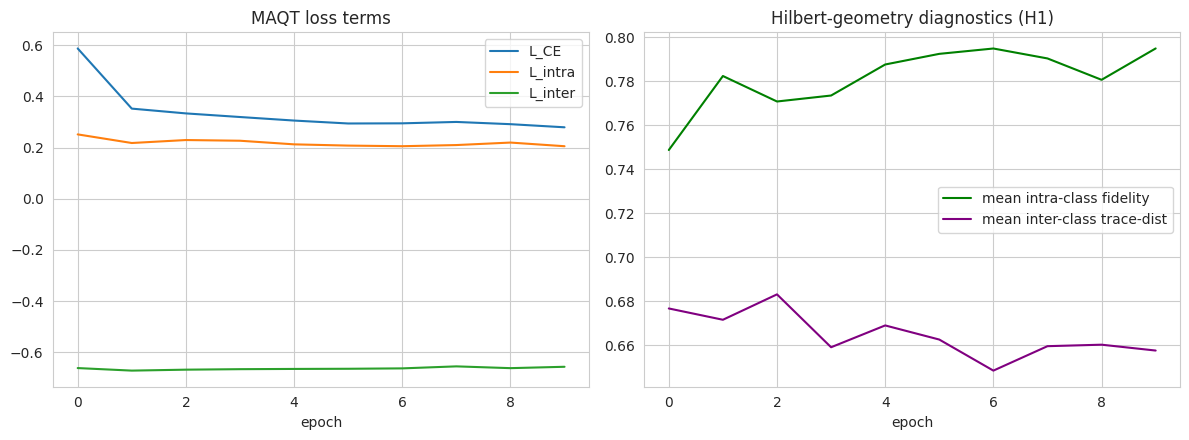

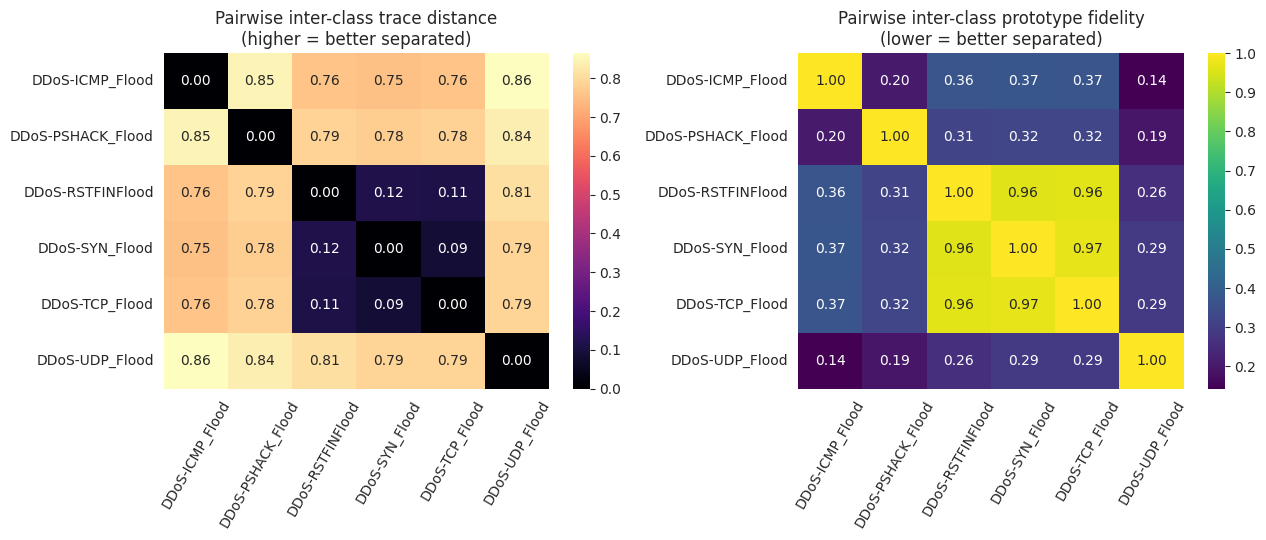

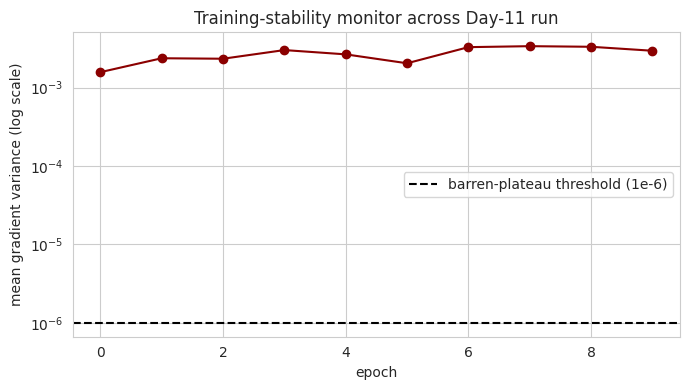

In [ ]:

# (DAY 11): End-to-end MAQT training + H1 diagnostics
#   (multiclass, N_CLASSES classes)

LR             = 0.05
EPOCHS         = 10
BATCH_SIZE     = 16
LAMBDA1_MAX    = 0.5
LAMBDA2_MAX    = 0.1
WARMUP_FRAC    = 0.2
GRAD_CLIP_NORM = 1.0
EMA_MOMENTUM   = 0.9
FOCAL_GAMMA    = 2.0

def curriculum_weight(epoch, total_epochs, base, warmup_frac=WARMUP_FRAC):
    warmup = max(int(warmup_frac * total_epochs), 1)
    return base * min(1.0, epoch / warmup)


def train_maqt(X_train_t, y_train_t, n_classes, epochs=EPOCHS,
               lam1_max=LAMBDA1_MAX, lam2_max=LAMBDA2_MAX, log_every=1, verbose=True):
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, n_classes).to(device)
    opt = torch.optim.Adam(list([theta]) + list(head.parameters()), lr=LR)
    protos = RunningPrototypes(momentum=EMA_MOMENTUM)

    y_cpu = y_train_t.cpu().numpy().astype(int)
    class_counts = np.bincount(y_cpu, minlength=n_classes)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_cpu]

    history = {"loss": [], "L_CE": [], "L_intra": [], "L_inter": [],
               "grad_var": [], "intra_fid_gap": [], "inter_trace_dist": []}

    for epoch in range(epochs):
        lam1 = curriculum_weight(epoch, epochs, lam1_max)
        lam2 = curriculum_weight(epoch, epochs, lam2_max)
        sampler = list(WeightedRandomSampler(sample_weights, num_samples=len(y_train_t), replacement=True))
        perm = torch.tensor(sampler)

        epoch_terms = {"L_total": [], "L_CE": [], "L_intra": [], "L_inter": []}
        grad_vars, intra_fid_running = [], []

        for i in range(0, len(perm), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)

            rho_batch = state_circuit_batched(xb, theta)
            z_batch = expvals_from_rho_batch(rho_batch)
            logits = head(z_batch.to(torch.float32))

            loss, terms = maqt_loss(rho_batch, yb, logits, protos, lam1, lam2, gamma=FOCAL_GAMMA)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list([theta]) + list(head.parameters()), GRAD_CLIP_NORM)
            grad_vars.append(theta.grad.var().item())
            opt.step()

            for k in epoch_terms:
                epoch_terms[k].append(terms[k])
            intra_fid_running.append(1 - terms["L_intra"])

        diag = protos.diagnostics()
        mean_inter_td = np.mean(list(diag.values())) if diag else 0.0
        mean_gv = np.mean(grad_vars)

        history["loss"].append(np.mean(epoch_terms["L_total"]))
        history["L_CE"].append(np.mean(epoch_terms["L_CE"]))
        history["L_intra"].append(np.mean(epoch_terms["L_intra"]))
        history["L_inter"].append(np.mean(epoch_terms["L_inter"]))
        history["grad_var"].append(mean_gv)
        history["intra_fid_gap"].append(np.mean(intra_fid_running))
        history["inter_trace_dist"].append(mean_inter_td)

        if verbose and (epoch + 1) % log_every == 0:
            print(f"epoch {epoch+1:2d}/{epochs} | loss {history['loss'][-1]:.4f} | "
                  f"L_CE {history['L_CE'][-1]:.4f} | L_intra {history['L_intra'][-1]:.4f} | "
                  f"L_inter {history['L_inter'][-1]:.4f} | grad_var {mean_gv:.2e} | "
                  f"intra_fid {history['intra_fid_gap'][-1]:.3f} | inter_TD {mean_inter_td:.3f}")
            if mean_gv < 1e-6:
                print("  barren plateau detected")

    if verbose:
        print("\n[H1 diagnostic] pairwise inter-class trace distances:")
        for k, v in protos.diagnostics().items():
            print(f"  {k}: {v:.4f}")
    return theta, head, protos, history



X_train_t = torch.tensor(A_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long, device=device)
X_test_t  = torch.tensor(A_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long, device=device)
X_cal_t   = torch.tensor(A_cal,   dtype=torch.float32, device=device)
y_cal_t   = torch.tensor(y_cal.values,   dtype=torch.long, device=device)
X_zday_t  = torch.tensor(A_zday,  dtype=torch.float32, device=device)

theta, head, protos, history = train_maqt(X_train_t, y_train_t, n_classes=N_CLASSES)

#  loss curves + H1 diagnostics 
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(history["L_CE"], label="L_CE")
ax[0].plot(history["L_intra"], label="L_intra")
ax[0].plot(history["L_inter"], label="L_inter")
ax[0].set_title("MAQT loss terms"); ax[0].legend(); ax[0].set_xlabel("epoch")

ax[1].plot(history["intra_fid_gap"], label="mean intra-class fidelity", color="green")
ax[1].plot(history["inter_trace_dist"], label="mean inter-class trace-dist", color="purple")
ax[1].set_title("Hilbert-geometry diagnostics (H1)"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

#  full N x N inter-class trace-distance heatmap 
td_matrix, class_keys = protos.pairwise_matrix(metric="trace_distance")
fid_matrix, _         = protos.pairwise_matrix(metric="fidelity")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(td_matrix, annot=True, fmt=".2f", cmap="magma",
            xticklabels=[CLASS_NAMES[k] for k in class_keys],
            yticklabels=[CLASS_NAMES[k] for k in class_keys], ax=ax[0])
ax[0].set_title("Pairwise inter-class trace distance\n(higher = better separated)")
ax[0].tick_params(axis='x', rotation=60)

sns.heatmap(fid_matrix, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[CLASS_NAMES[k] for k in class_keys],
            yticklabels=[CLASS_NAMES[k] for k in class_keys], ax=ax[1])
ax[1].set_title("Pairwise inter-class prototype fidelity\n(lower = better separated)")
ax[1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()

#   gradient-variance stability over training
plt.figure(figsize=(7, 4))
plt.plot(history["grad_var"], marker='o', color="darkred")
plt.axhline(1e-6, color="black", linestyle="--", label="barren-plateau threshold (1e-6)")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("mean gradient variance (log scale)")
plt.title("Training-stability monitor across Day-11 run")
plt.legend(); plt.tight_layout(); plt.show()

                   precision    recall  f1-score   support

  DDoS-ICMP_Flood       1.00      0.97      0.98       994
DDoS-PSHACK_Flood       0.96      0.98      0.97       549
 DDoS-RSTFINFlood       0.35      0.84      0.49       564
   DDoS-SYN_Flood       0.42      0.07      0.12       560
   DDoS-TCP_Flood       0.34      0.16      0.21       611
   DDoS-UDP_Flood       0.97      0.98      0.98       722

         accuracy                           0.70      4000
        macro avg       0.67      0.67      0.62      4000
     weighted avg       0.71      0.70      0.67      4000



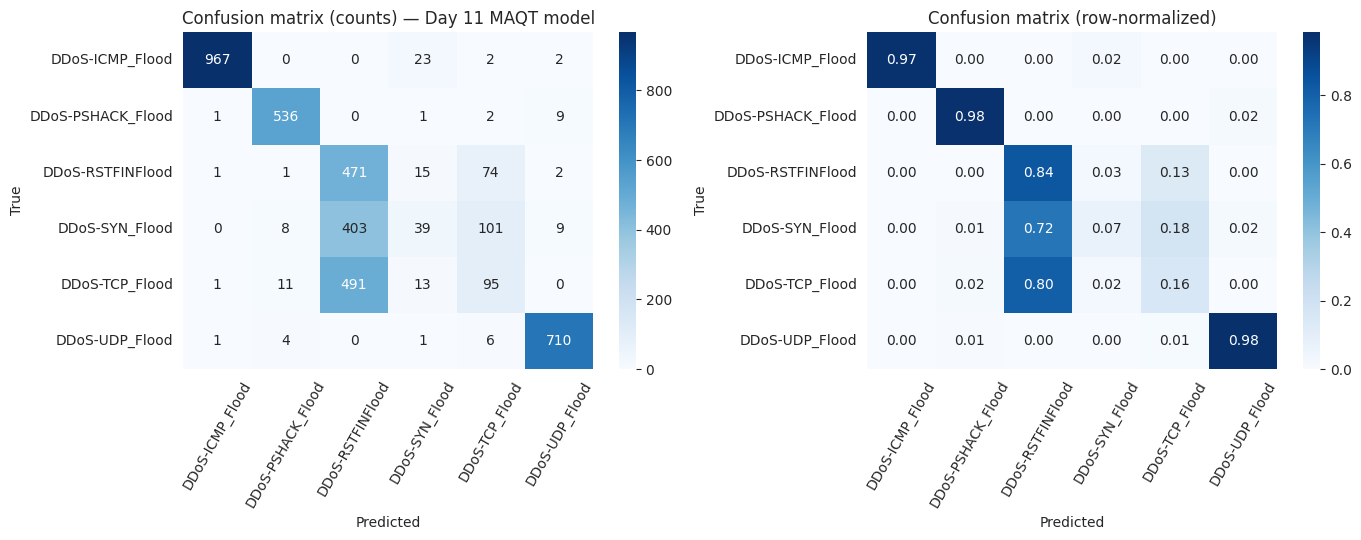

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report

def maqt_logits(x_batch, theta_, head_):
    rho_batch = state_circuit_batched(x_batch, theta_)
    z_batch = expvals_from_rho_batch(rho_batch)
    return head_(z_batch.to(torch.float32))

@torch.no_grad()
def batched_predict(X_t, theta_, head_, batch_size=64):
    preds = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].to(device)
        logits = maqt_logits(xb, theta_, head_)
        preds.append(logits.argmax(1).cpu())
    return torch.cat(preds).numpy()

y_pred_test = batched_predict(X_test_t, theta, head)
y_true_test = y_test_t.cpu().numpy()

print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true_test, y_pred_test, labels=range(N_CLASSES))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title("Confusion matrix (counts) — Day 11 MAQT model")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[0].tick_params(axis='x', rotation=60)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[1])
ax[1].set_title("Confusion matrix (row-normalized)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
ax[1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()

[plain VQC] epoch 1/8 loss 0.9936
[plain VQC] epoch 2/8 loss 1.0089
[plain VQC] epoch 3/8 loss 0.5952
[plain VQC] epoch 4/8 loss 0.4856
[plain VQC] epoch 5/8 loss 0.9569
[plain VQC] epoch 6/8 loss 0.6280
[plain VQC] epoch 7/8 loss 0.6252
[plain VQC] epoch 8/8 loss 0.6341

[FGSM] clean_acc=0.710 adv_acc=0.531 degradation=0.179
[PGD]  clean_acc=0.710 adv_acc=0.585 degradation=0.126


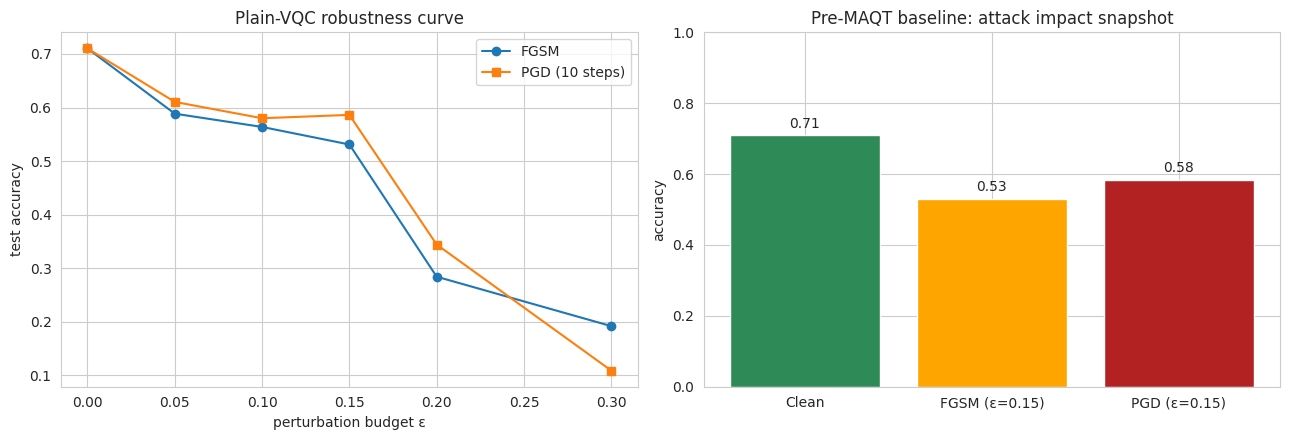


Attack framework validated against the pre-MAQT baseline.


In [ ]:

# (DAY 12): FGSM + PGD attacks, validated on plain VQC

def plain_vqc_logits(x_batch, theta_, head_):
    rho_batch = state_circuit_batched(x_batch, theta_)
    z_batch = expvals_from_rho_batch(rho_batch)
    return head_(z_batch.to(torch.float32))


def fgsm_attack(x_batch, y_batch, theta_, head_, epsilon, loss_fn=nn.CrossEntropyLoss()):
    x_batch = x_batch.clone().detach().requires_grad_(True)
    logits = plain_vqc_logits(x_batch, theta_, head_)
    loss = loss_fn(logits, y_batch)
    grad = torch.autograd.grad(loss, x_batch)[0]
    x_adv = x_batch + epsilon * grad.sign()
    return torch.clamp(x_adv, 0.0, np.pi).detach()


def pgd_attack(x_batch, y_batch, theta_, head_, epsilon, alpha, n_steps,
               loss_fn=nn.CrossEntropyLoss(), random_start=True):
    x_orig = x_batch.clone().detach()
    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(x_adv, 0.0, np.pi).detach()
    else:
        x_adv = x_orig.clone()

    for _ in range(n_steps):
        x_adv.requires_grad_(True)
        logits = plain_vqc_logits(x_adv, theta_, head_)
        loss = loss_fn(logits, y_batch)
        grad = torch.autograd.grad(loss, x_adv)[0]
        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            x_adv = torch.max(torch.min(x_adv, x_orig + epsilon), x_orig - epsilon)
            x_adv = torch.clamp(x_adv, 0.0, np.pi)
    return x_adv.detach()


def evaluate_attack(X, y, theta_, head_, attack_fn, **kwargs):
    with torch.no_grad():
        clean_acc = (plain_vqc_logits(X, theta_, head_).argmax(1) == y).float().mean().item()
    X_adv = attack_fn(X, y, theta_, head_, **kwargs)
    with torch.no_grad():
        adv_acc = (plain_vqc_logits(X_adv, theta_, head_).argmax(1) == y).float().mean().item()
    return clean_acc, adv_acc, X_adv


def train_plain_vqc(X_train_t, y_train_t, n_classes, epochs=8, lr=0.05, batch_size=16):
    theta_p = init_theta_identity_block()
    head_p = nn.Linear(N_QUBITS, n_classes).to(device)
    opt = torch.optim.Adam(list([theta_p]) + list(head_p.parameters()), lr=lr)
    ce = nn.CrossEntropyLoss()
    n = len(X_train_t)
    losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
            logits = plain_vqc_logits(xb, theta_p, head_p)
            loss = ce(logits, yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(list([theta_p]) + list(head_p.parameters()), 1.0)
            opt.step()
        losses.append(loss.item())
        print(f"[plain VQC] epoch {epoch+1}/{epochs} loss {loss.item():.4f}")
    return theta_p, head_p, losses


theta_plain, head_plain, plain_losses = train_plain_vqc(X_train_t, y_train_t, n_classes=N_CLASSES)

#  FGSM at a single epsilon
clean_acc, fgsm_acc, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain,
                                          fgsm_attack, epsilon=0.15)
print(f"\n[FGSM] clean_acc={clean_acc:.3f} adv_acc={fgsm_acc:.3f} degradation={clean_acc-fgsm_acc:.3f}")

#  PGD at a single epsilon 
clean_acc2, pgd_acc, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain,
                                          pgd_attack, epsilon=0.15, alpha=0.03, n_steps=10)
print(f"[PGD]  clean_acc={clean_acc2:.3f} adv_acc={pgd_acc:.3f} degradation={clean_acc2-pgd_acc:.3f}")

# accuracy-vs-perturbation-strength curve
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
fgsm_accs, pgd_accs = [], []
for eps in epsilons:
    if eps == 0.0:
        fgsm_accs.append(clean_acc); pgd_accs.append(clean_acc2)
        continue
    _, fa, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain, fgsm_attack, epsilon=eps)
    _, pa, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain, pgd_attack,
                                epsilon=eps, alpha=eps/5, n_steps=10)
    fgsm_accs.append(fa); pgd_accs.append(pa)

#  robustness curves , bar chart
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(epsilons, fgsm_accs, marker='o', label="FGSM")
ax[0].plot(epsilons, pgd_accs, marker='s', label="PGD (10 steps)")
ax[0].set_xlabel("perturbation budget ε"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("Plain-VQC robustness curve"); ax[0].legend()

bars = ax[1].bar(["Clean", "FGSM (ε=0.15)", "PGD (ε=0.15)"],
                  [clean_acc, fgsm_acc, pgd_acc], color=["seagreen", "orange", "firebrick"])
ax[1].set_ylabel("accuracy"); ax[1].set_ylim(0, 1)
ax[1].set_title("Pre-MAQT baseline: attack impact snapshot")
for b in bars:
    ax[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{b.get_height():.2f}", ha='center')
plt.tight_layout(); plt.show()

print("\nAttack framework validated against the pre-MAQT baseline." if fgsm_acc < clean_acc
      else "\n⚠ FGSM did not degrade accuracy — inspect attack wiring before trusting Prop-2 validation.")

λ1=0.10 λ2=0.02 -> inter_TD=0.607 intra_fid=0.761 min_gv=1.24e-03 stable=True
λ1=0.10 λ2=0.50 -> inter_TD=0.633 intra_fid=0.781 min_gv=1.28e-03 stable=True
λ1=0.50 λ2=0.02 -> inter_TD=0.648 intra_fid=0.810 min_gv=1.52e-03 stable=True
λ1=0.50 λ2=0.50 -> inter_TD=0.657 intra_fid=0.768 min_gv=1.31e-03 stable=True

=== λ1/λ2 SENSITIVITY REPORT ===
 lambda1  lambda2  mean_inter_TD  mean_intra_fid  min_grad_var  stable    score
     0.5     0.02       0.647916        0.810359      0.001517    True 1.458274
     0.5     0.50       0.656853        0.768215      0.001306    True 1.425067
     0.1     0.50       0.632699        0.781257      0.001277    True 1.413956
     0.1     0.02       0.606765        0.761055      0.001242    True 1.367821

Recommended operating point: λ1=0.5, λ2=0.02 (inter_TD=0.648, intra_fid=0.810, stable=True)


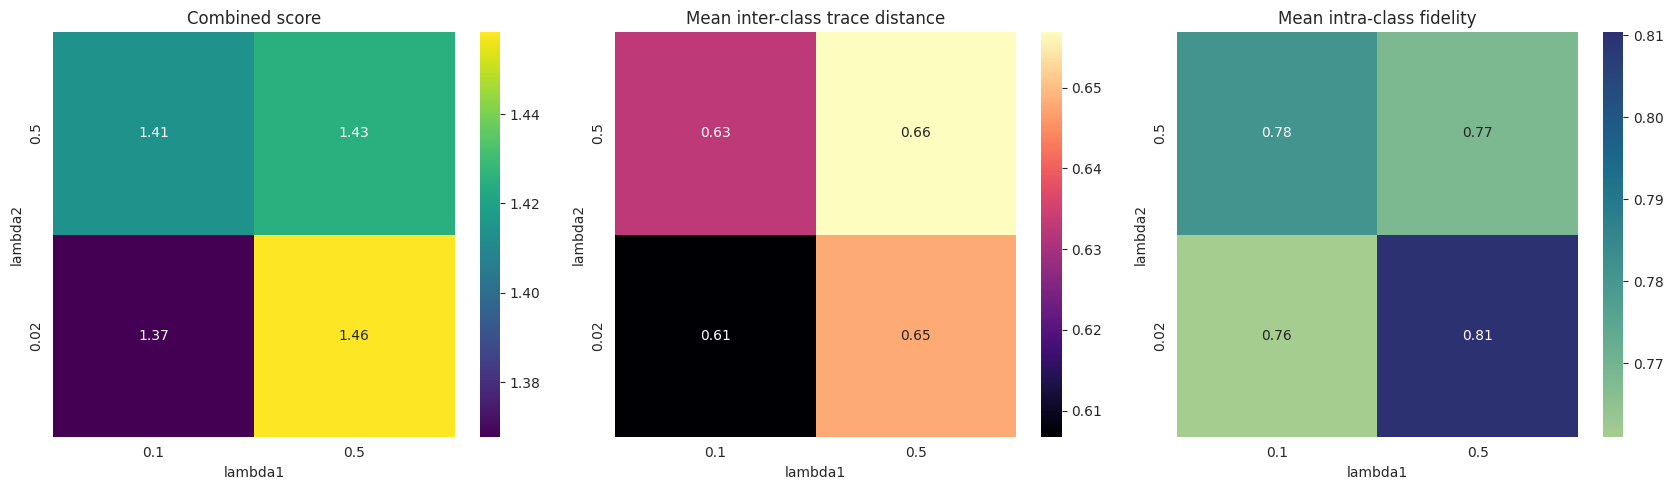

In [ ]:

# (DAY 13): λ1/λ2 sweep for tight, separated multiclass prototypes

def run_lambda_sweep(X_train_t, y_train_t, n_classes,
                      lambda1_grid=(0.1, 0.5),
                      lambda2_grid=(0.02, 0.5),
                      epochs=2):
    records = []
    for lam1_max in lambda1_grid:
        for lam2_max in lambda2_grid:
            _, _, protos_sweep, hist = train_maqt(
                X_train_t, y_train_t, n_classes,
                epochs=epochs, lam1_max=lam1_max, lam2_max=lam2_max, verbose=False
            )
            diag = protos_sweep.diagnostics()
            mean_inter_td = np.mean(list(diag.values())) if diag else 0.0
            final_intra_fid = hist["intra_fid_gap"][-1]
            min_grad_var = min(hist["grad_var"])

            records.append({
                "lambda1": lam1_max, "lambda2": lam2_max,
                "mean_inter_TD": mean_inter_td, "mean_intra_fid": final_intra_fid,
                "min_grad_var": min_grad_var, "stable": min_grad_var > 1e-6
            })
            print(f"λ1={lam1_max:.2f} λ2={lam2_max:.2f} -> inter_TD={mean_inter_td:.3f} "
                  f"intra_fid={final_intra_fid:.3f} min_gv={min_grad_var:.2e} "
                  f"stable={min_grad_var > 1e-6}")
    return records


sweep_records = run_lambda_sweep(X_train_t, y_train_t, n_classes=N_CLASSES, epochs=6)

df_sweep = pd.DataFrame(sweep_records)
df_sweep["score"] = df_sweep["mean_inter_TD"] + df_sweep["mean_intra_fid"] - (~df_sweep["stable"]).astype(int)
best_row = df_sweep.sort_values("score", ascending=False).iloc[0]

print("\n=== λ1/λ2 SENSITIVITY REPORT ===")
print(df_sweep.sort_values("score", ascending=False).to_string(index=False))
print(f"\nRecommended operating point: λ1={best_row['lambda1']}, λ2={best_row['lambda2']} "
      f"(inter_TD={best_row['mean_inter_TD']:.3f}, intra_fid={best_row['mean_intra_fid']:.3f}, "
      f"stable={bool(best_row['stable'])})")

LAMBDA1_MAX = float(best_row["lambda1"])
LAMBDA2_MAX = float(best_row["lambda2"])

#  sweep heatmaps
pivot_score = df_sweep.pivot(index="lambda2", columns="lambda1", values="score")
pivot_td    = df_sweep.pivot(index="lambda2", columns="lambda1", values="mean_inter_TD")
pivot_fid   = df_sweep.pivot(index="lambda2", columns="lambda1", values="mean_intra_fid")

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
sns.heatmap(pivot_score, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
ax[0].set_title("Combined score"); ax[0].invert_yaxis()

sns.heatmap(pivot_td, annot=True, fmt=".2f", cmap="magma", ax=ax[1])
ax[1].set_title("Mean inter-class trace distance"); ax[1].invert_yaxis()

sns.heatmap(pivot_fid, annot=True, fmt=".2f", cmap="crest", ax=ax[2])
ax[2].set_title("Mean intra-class fidelity"); ax[2].invert_yaxis()

plt.tight_layout(); plt.show()

In [ ]:


import pickle, os

print(f"Using tuned hyperparameters: λ1_max={LAMBDA1_MAX}, λ2_max={LAMBDA2_MAX}")

theta_final, head_final, protos_final, history_final = train_maqt(
    X_train_t, y_train_t, n_classes=N_CLASSES,
    epochs=10, lam1_max=LAMBDA1_MAX, lam2_max=LAMBDA2_MAX
)

final_diag = protos_final.diagnostics()
print("\n=== Final Hilbert-geometry diagnostics (multiclass) ===")
for k, v in final_diag.items():
    print(f"  {k}: {v:.4f}")

sep_ok = all(v > 0.15 for v in final_diag.values()) if final_diag else False
print(f"Proposition 2 separability precondition satisfied (all pairs > 0.15): {sep_ok}")

# --- final test-set evaluation ---
y_pred_final = batched_predict(X_test_t, theta_final, head_final)
print("\nFinal classification report:")
print(classification_report(y_true_test, y_pred_final, target_names=CLASS_NAMES, zero_division=0))


ckpt_dir = "/kaggle/working/Quantum_ML/Team_B/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

checkpoint = {
    "theta": theta_final.detach().cpu(),
    "head_state_dict": head_final.state_dict(),
    "N_QUBITS": N_QUBITS, "N_LAYERS": N_LAYERS, "NOISE_P": NOISE_P,
    "lambda1_max": LAMBDA1_MAX, "lambda2_max": LAMBDA2_MAX,
    "history": history_final,
    "scaler_mean": scaler.mean_, "scaler_scale": scaler.scale_,
    "pca_components": pca.components_, "pca_mean": pca.mean_,
    "pca_n_components": pca.n_components_,
    "class_names": CLASS_NAMES,
    "label_encoder_classes": le.classes_,
}
ckpt_path = os.path.join(ckpt_dir, "maqt_day14_multiclass.pt")
torch.save(checkpoint, ckpt_path)
print(f"\nSaved MAQT checkpoint -> {ckpt_path}")


proto_export = {c: rho.detach().cpu().numpy() for c, rho in protos_final.protos.items()}
proto_path = "/kaggle/working/prototypes_multiclass.pkl"
with open(proto_path, "wb") as f:
    pickle.dump({"prototypes": proto_export, "class_names": CLASS_NAMES}, f)
print(f"Published prototype density matrices -> {proto_path}")
print(f"Classes exported: {[CLASS_NAMES[k] for k in proto_export.keys()]}")


final_cm = confusion_matrix(y_true_test, y_pred_final, labels=range(N_CLASSES))
final_cm_norm = final_cm.astype(float) / (final_cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(2, 2, figsize=(15, 12))

sns.heatmap(final_cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0, 0])
ax[0, 0].set_title("Final confusion matrix (row-normalized)")
ax[0, 0].tick_params(axis='x', rotation=60)

final_td_matrix, final_keys = protos_final.pairwise_matrix(metric="trace_distance")
sns.heatmap(final_td_matrix, annot=True, fmt=".2f", cmap="magma",
            xticklabels=[CLASS_NAMES[k] for k in final_keys],
            yticklabels=[CLASS_NAMES[k] for k in final_keys], ax=ax[0, 1])
ax[0, 1].set_title("Final pairwise inter-class trace distance")
ax[0, 1].tick_params(axis='x', rotation=60)

ax[1, 0].plot(history_final["loss"], label="total loss")
ax[1, 0].plot(history_final["L_CE"], label="L_CE")
ax[1, 0].plot(history_final["L_intra"], label="L_intra")
ax[1, 0].plot(history_final["L_inter"], label="L_inter")
ax[1, 0].set_title("Day-14 final retrain — loss curves")
ax[1, 0].set_xlabel("epoch"); ax[1, 0].legend()

ax[1, 1].plot(history_final["intra_fid_gap"], label="mean intra-class fidelity", color="green")
ax[1, 1].plot(history_final["inter_trace_dist"], label="mean inter-class trace-dist", color="purple")
ax[1, 1].set_title("Day-14 final retrain — Hilbert-geometry diagnostics")
ax[1, 1].set_xlabel("epoch"); ax[1, 1].legend()

plt.tight_layout(); plt.show()

# --- per-class precision/recall/F1 bar chart ---
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, support = precision_recall_fscore_support(y_true_test, y_pred_final,
                                                           labels=range(N_CLASSES), zero_division=0)
x = np.arange(N_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, prec, width, label="precision", color="steelblue")
ax.bar(x,          rec,  width, label="recall",    color="darkorange")
ax.bar(x + width,  f1,   width, label="f1-score",  color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=60)
ax.set_ylim(0, 1.05); ax.set_title("Per-class precision / recall / F1 (final model)")
ax.legend(); plt.tight_layout(); plt.show()

print("\n===  SUMMARY (MULTICLASS) ===")
print(f"Classes used ({N_CLASSES}): {CLASS_NAMES}")
print(f"Final train loss:        {history_final['loss'][-1]:.4f}")
print(f"Final intra-class fid:   {history_final['intra_fid_gap'][-1]:.4f}")
print(f"Final inter-class TD:    {history_final['inter_trace_dist'][-1]:.4f}")
print(f"Min grad variance seen:  {min(history_final['grad_var']):.2e}")
print("Ready  conformal calibration on 'prototypes_multiclass.pkl'.")